In [29]:
""" Cell 1: Setup & Core Functions """
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances, rbf_kernel
from scipy.sparse.linalg import eigsh
from scipy.sparse.csgraph import shortest_path
from sklearn.neighbors import kneighbors_graph
from scipy.stats import gaussian_kde
from scipy.linalg import orthogonal_procrustes # Added for sensitivity analysis
import gudhi
import warnings
warnings.filterwarnings('ignore')

os.makedirs("../figures", exist_ok=True)

# ---------- Matplotlib Configuration ----------
sns.set_theme(style="ticks") 
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rc('font', size=12)
plt.rc('axes', labelsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('legend', fontsize=10)

print("Global plotting settings loaded.")

# ---------- Utilities ----------
def compute_diffusion_map(X, n_components=2, epsilon=None, t=1):
    D = euclidean_distances(X)
    if epsilon is None:
        epsilon = np.median(D[D > 0])
    
    W = rbf_kernel(X, gamma=1/(2*epsilon**2))
    np.fill_diagonal(W, 0)
    
    d_inv_sqrt = 1.0 / np.sqrt(W.sum(axis=1))
    A = d_inv_sqrt[:, None] * W * d_inv_sqrt[None, :] 
    
    eigvals, eigvecs = eigsh(A, k=n_components+1, which='LM')
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx][1:n_components+1]
    eigvecs = eigvecs[:, idx][:, 1:n_components+1] 
    
    for i in range(eigvecs.shape[1]):
        max_abs_idx = np.argmax(np.abs(eigvecs[:, i]))
        sign = np.sign(eigvecs[max_abs_idx, i])
        eigvecs[:, i] *= sign
        
    coords = eigvecs * (eigvals ** t)
    return coords, eigvecs, eigvals, epsilon

def nystrom_projection(X_new, X_train, eigvecs, eigvals, epsilon, t=1):
    K_new_train = rbf_kernel(X_new, X_train, gamma=1/(2*epsilon**2))
    d_train = np.sum(rbf_kernel(X_train, X_train, gamma=1/(2*epsilon**2)), axis=1)
    d_new = np.sum(K_new_train, axis=1)
    
    d_inv_sqrt_train = 1.0 / np.sqrt(d_train)
    d_inv_sqrt_new = 1.0 / np.sqrt(d_new)
    
    K_normalized = d_inv_sqrt_new[:, None] * K_new_train * d_inv_sqrt_train[None, :]
    psi_new = (K_normalized @ eigvecs) / eigvals
    return psi_new * (eigvals ** t)

def calculate_trajectory_metrics(group, geo_dist_matrix, global_indices):
    coords = group[["Diff1", "Diff2"]].values
    
    start_pos, end_pos = coords[0], coords[-1]
    net_displacement = np.linalg.norm(end_pos - start_pos)
    
    total_euc_path = 0
    total_geo_path = 0
    
    for i in range(len(coords) - 1):
        step_dist = np.linalg.norm(coords[i+1] - coords[i])
        total_euc_path += step_dist
        
        curr_idx = global_indices[group.index[i]]
        nxt_idx = global_indices[group.index[i+1]]
        geo_step = geo_dist_matrix[curr_idx, nxt_idx]
        
        if not np.isinf(geo_step):
            total_geo_path += geo_step
            
    tortuosity = total_euc_path / net_displacement if net_displacement > 0 else np.inf
    inefficiency = total_geo_path / total_euc_path if total_euc_path > 0 else np.nan
    
    return tortuosity, inefficiency

def compute_manifold_stability(var_subsets, data, n_components=2):
    """Computes alignment between manifolds from different variable sets using Procrustes."""
    scaler = StandardScaler()
    results = {}
    
    for name, vars_list in var_subsets.items():
        X_sub = scaler.fit_transform(data[vars_list])
        coords, _, _, _ = compute_diffusion_map(X_sub, n_components=n_components)
        results[name] = coords
        
    baseline = results['vdem_core']
    alignment_scores = {}
    
    for name, coords in results.items():
        if name != 'vdem_core':
            # Find optimal orthogonal rotation to align with baseline
            R, _ = orthogonal_procrustes(coords, baseline)
            aligned_coords = coords @ R
            # Calculate correlation of flattened coordinate arrays
            corr = np.corrcoef(baseline.flatten(), aligned_coords.flatten())[0, 1]
            alignment_scores[name] = corr
            
    return alignment_scores

Global plotting settings loaded.


In [30]:
""" Cell 2: Data Import & Cleaning """
df = pd.read_csv("../data/qog_std_cs_jan26.csv", low_memory=False)
df_ts = pd.read_csv("../data/qog_std_ts_jan26.csv", low_memory=False)

vdem_features = ['vdem_polyarchy', 'vdem_egal', 'vdem_corr']
wdi_features = ['wdi_popurb', 'wdi_lifexp', 'wdi_gdpcapcur']
undp_features = ['undp_hdi']

# FIX: Update the column selection to use your newly named lists
data = df[["cname"] + vdem_core + wdi_core + undp_core].copy().replace([-5, -4, -3, -2, -1, -9999], np.nan)
data["wdi_gdpcapcur"] = pd.to_numeric(data["wdi_gdpcapcur"], errors='coerce')

# K-NN imputation chosen over listwise deletion to prevent systematically dropping autocratic regimes
numeric_cols = data.select_dtypes(include=[np.number]).columns
imputer = KNNImputer(n_neighbors=5, add_indicator=False)
data_clean = pd.DataFrame(imputer.fit_transform(data[numeric_cols]), columns=numeric_cols, index=data["cname"])
data_clean["cname"] = data["cname"].values

var_subsets = {
    'vdem_core': vdem_features, 
    'vdem, wdi': vdem_features + wdi_features, # The variables defining our primary manifold
    'vdem, wdi, undp': vdem_features + wdi_features + undp_features # Testing distortion with redundant structural features
}

alignment_scores = compute_manifold_stability(var_subsets, data_clean)
print("\n--- Manifold Stability (Procrustes Alignment vs. Core Institutional V-Dem Model) ---")
for name, score in alignment_scores.items():
    print(f"{name:15}: r = {score:.4f}")
print("------------------------------------------------------------------------------------\n")


--- Manifold Stability (Procrustes Alignment vs. Core Institutional V-Dem Model) ---
vdem, wdi      : r = 0.9020
vdem, wdi, undp: r = 0.8528
------------------------------------------------------------------------------------



Reference diffusion manifold created. Epsilon = 2.8754

--- Empirical Axis Correlations (Spearman) ---
vdem_polyarchy : Diff1 = +0.811 | Diff2 = -0.349
vdem_egal      : Diff1 = +0.877 | Diff2 = -0.307
vdem_corr      : Diff1 = -0.890 | Diff2 = +0.179
wdi_popurb     : Diff1 = +0.611 | Diff2 = +0.645
wdi_lifexp     : Diff1 = +0.748 | Diff2 = +0.434
undp_hdi       : Diff1 = +0.766 | Diff2 = +0.385
log_gdp        : Diff1 = +0.737 | Diff2 = +0.442
----------------------------------------------



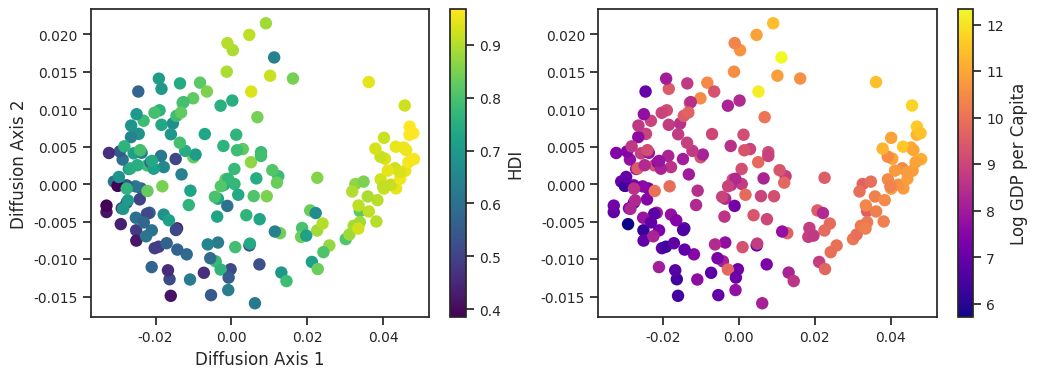

In [34]:
""" Cell 3: Reference Manifold & Axes Diagnostics """
# Train only on the 6 theoretically justified variables
core_features = vdem_features + wdi_features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_clean[core_features])

diff_coords, diff_eigvecs, diff_eigvals, diff_eps = compute_diffusion_map(X_scaled, n_components=2, t=1)
data_clean["Diff1"] = diff_coords[:, 0]
data_clean["Diff2"] = diff_coords[:, 1]

# Create log_gdp for coloring the plot
data_clean["log_gdp"] = np.log(data_clean["wdi_gdpcapcur"])
print(f"Reference diffusion manifold created. Epsilon = {diff_eps:.4f}")

# Empirical diagnostic to calculate axes meanings
print("\n--- Empirical Axis Correlations (Spearman) ---")
# Filter out raw GDP to avoid printing redundant Spearman correlations, 
# but include HDI and Log GDP as external interpreters.
diagnostic_cols = [c for c in core_features if c != "wdi_gdpcapcur"] + ["undp_hdi", "log_gdp"]

for col in diagnostic_cols:
    corr1 = data_clean[col].corr(data_clean["Diff1"], method="spearman")
    corr2 = data_clean[col].corr(data_clean["Diff2"], method="spearman")
    print(f"{col:15}: Diff1 = {corr1:+.3f} | Diff2 = {corr2:+.3f}")
print("----------------------------------------------\n")

# Reference Manifold (side-by-side comparison)
with plt.rc_context({'text.usetex': False, 'ps.usedistiller': None, 'axes.unicode_minus': False}):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Colored by HDI (External validation)
    sc1 = axes[0].scatter(data_clean["Diff1"], data_clean["Diff2"], c=data_clean["undp_hdi"], 
                          cmap='viridis', s=80, edgecolor='none', linewidth=0.5)
    fig.colorbar(sc1, ax=axes[0], label="HDI")
    axes[0].set_xlabel("Diffusion Axis 1")
    axes[0].set_ylabel("Diffusion Axis 2")
    
    # Colored by Log GDP (Reveals the rentier state anomaly)
    sc2 = axes[1].scatter(data_clean["Diff1"], data_clean["Diff2"], c=data_clean["log_gdp"], 
                          cmap='plasma', s=80, edgecolor='none', linewidth=0.5)
    fig.colorbar(sc2, ax=axes[1], label="Log GDP per Capita")
    
    # Save figures
    plt.savefig("../figures/fig1_reference_manifold.png", dpi=300, bbox_inches='tight')
    plt.savefig("../figures/fig1_reference_manifold.eps", bbox_inches='tight')
    plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


H1 -> High-dimensional loops (developmental voids) detected: 40

--- Primary Void Characteristics (Mean values bounding the hole) ---
vdem_polyarchy     0.331828
vdem_egal          0.472055
vdem_corr          0.492566
wdi_popurb        61.633201
wdi_lifexp        69.003977
dtype: float64


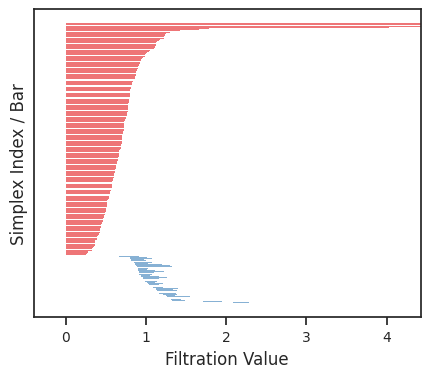

In [35]:
""" Cell 4: TDA & Identifying the Primary Void """
D_high = euclidean_distances(X_scaled)
search_radius = np.median(D_high[D_high > 0]) * 1.5  

rips_complex_hd = gudhi.RipsComplex(points=X_scaled, max_edge_length=search_radius)
simplex_tree_hd = rips_complex_hd.create_simplex_tree(max_dimension=2)
diag_hd = simplex_tree_hd.persistence(homology_coeff_field=2, min_persistence=0.1)

loops_h1 = [f for f in diag_hd if f[0] == 1]
print(f"H1 -> High-dimensional loops (developmental voids) detected: {len(loops_h1)}")

# Isolate the deepest topological void using KDE inverse to find the "hole" in the data
kde = gaussian_kde(X_scaled.T)
density = kde(X_scaled.T)

# Find points bounding the lowest density region in the center of the manifold
threshold = np.percentile(density, 15)
void_bounds = data_clean[density < threshold]
print("\n--- Primary Void Characteristics (Mean values bounding the hole) ---")
print(void_bounds[features_ts].mean())

# Persistence Barcode
# Force shutdown of the Ghostscript path for this specific figure
with plt.rc_context({
    'text.usetex': False, 
    'ps.usedistiller': None, 
    'pdf.fonttype': 42,
    'pgf.texsystem': 'pdflatex' # Redirects internal logic away from GS
}):
    # Capture the axes from the GUDHI plot directly
    fig, ax = plt.subplots(figsize=(5, 4))
    gudhi.plot_persistence_barcode(diag_hd, axes=ax)
    ax.set_title("")                         # Remove default GUDHI title
    ax.set_xlabel("Filtration Value")        # Label for the x-axis
    ax.set_ylabel("Simplex Index / Bar")     # Label for the y-axis
    leg = ax.get_legend()
    if leg:
        leg.remove()                         # Remove the default legend
    
    # Save figures
    plt.savefig("../figures/fig2_persistence_barcode.png", dpi=300, bbox_inches='tight')
    plt.savefig("../figures/fig2_persistence_barcode.eps", bbox_inches='tight')
    plt.show()

In [38]:
""" Cell 5: Historical Projection """
# Extract historical data using our validated 6-variable list
df_ts_clean = df_ts[["cname", "year"] + core_features].replace([-5, -4, -3, -2, -1, -9999], np.nan).dropna()
df_ts_clean = df_ts_clean[df_ts_clean["year"] >= 1990]

# Transform the historical data using the same scaler and variables as the reference manifold
X_ts_scaled = scaler.transform(df_ts_clean[core_features])

# Project the historical data onto the static geometry
X_diff_ts = nystrom_projection(X_ts_scaled, X_scaled, diff_eigvecs, diff_eigvals, diff_eps)

df_ts_clean["Diff1"] = X_diff_ts[:, 0]
df_ts_clean["Diff2"] = X_diff_ts[:, 1]
print(f"Projected {len(df_ts_clean)} historical observations (1990-2026).")

Projected 5628 historical observations (1990-2026).


In [39]:
""" Cell 6: Data-Driven Trajectory Typologies (K-Means) """
knn_graph = kneighbors_graph(X_diff_ts, n_neighbors=10, mode='distance', include_self=False)
geo_dist_matrix = shortest_path(csgraph=knn_graph, directed=False)
global_idx_map = {idx: i for i, idx in enumerate(df_ts_clean.index)}

results = []
for cname, group in df_ts_clean.groupby("cname"):
    if len(group) < 10: 
        continue
    tortuosity, inefficiency = calculate_trajectory_metrics(group, geo_dist_matrix, global_idx_map)
    
    # Filter out pure infinites to allow clustering
    if not np.isinf(tortuosity) and not np.isnan(inefficiency):
        results.append({
            "cname": cname,
            "Tortuosity": tortuosity,
            "Inefficiency": inefficiency
        })

df_typology = pd.DataFrame(results)

# Apply a log transformation to handle the extreme right-skew of the metrics
df_typology["log_Tortuosity"] = np.log(df_typology["Tortuosity"])
df_typology["log_Inefficiency"] = np.log(df_typology["Inefficiency"])

# Use K-Means on the log-transformed space
X_clust = df_typology[["log_Tortuosity", "log_Inefficiency"]].values
kmeans = KMeans(n_clusters=3, random_state=42).fit(X_clust)
df_typology["Cluster"] = kmeans.labels_

# Map cluster centroids to conceptual labels
centroids = kmeans.cluster_centers_
sorted_idx = np.argsort(centroids[:, 0]) # Sort by log_Tortuosity
label_map = {sorted_idx[0]: "Direct", sorted_idx[1]: "Meandering", sorted_idx[2]: "Erratic"}
df_typology["Typology"] = df_typology["Cluster"].map(label_map)

print("\nTrajectory Typology Counts (Data-Driven, Log-Transformed):")
print(df_typology["Typology"].value_counts())


Trajectory Typology Counts (Data-Driven, Log-Transformed):
Typology
Direct        88
Meandering    67
Erratic       15
Name: count, dtype: int64


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Representative Exemplars Selected: {'Direct': 'Dominican Republic (the)', 'Meandering': 'Mauritania', 'Erratic': 'Kyrgyzstan'}


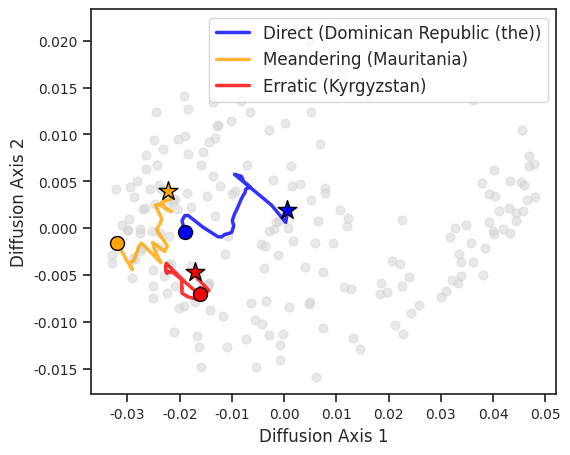

In [8]:
""" Cell 7: Visualizing Trajectories & Figure 3 """
# Scientifically rigorous exemplar selection: closest to the group median
examples = {}
for typo in ["Direct", "Meandering", "Erratic"]:
    subset = df_typology[df_typology["Typology"] == typo].copy()
    
    # Calculate group medians for the metrics
    med_tort = subset["Tortuosity"].median()
    med_ineff = subset["Inefficiency"].median()
    
    # Find the country with the minimum Euclidean distance to the group median
    subset["dist_to_median"] = np.sqrt(
        (subset["Tortuosity"] - med_tort)**2 + 
        (subset["Inefficiency"] - med_ineff)**2
    )
    
    # Extract the name of the most representative country
    exemplar = subset.loc[subset["dist_to_median"].idxmin(), "cname"]
    examples[typo] = exemplar

print(f"Representative Exemplars Selected: {examples}")

colors = {"Direct": "blue", "Meandering": "orange", "Erratic": "red"}

with plt.rc_context({'text.usetex': False, 'ps.usedistiller': None, 'axes.unicode_minus': False}):
    plt.figure(figsize=(6, 5))
    
    # Plot the background reference manifold
    plt.scatter(data_clean["Diff1"], data_clean["Diff2"], c='lightgrey', s=40, alpha=0.5, zorder=1)

    # Overlay the historical paths
    for typo, cname in examples.items():
        country_data = df_ts_clean[df_ts_clean["cname"] == cname].sort_values("year")
        x = country_data["Diff1"].values
        y = country_data["Diff2"].values
        
        plt.plot(x, y, color=colors[typo], label=f"{typo} ({cname})", linewidth=2.5, alpha=0.8, zorder=5)
        plt.scatter(x[0], y[0], color=colors[typo], marker='o', s=100, edgecolor='black', zorder=6)
        plt.scatter(x[-1], y[-1], color=colors[typo], marker='*', s=200, edgecolor='black', zorder=6)

    plt.xlabel("Diffusion Axis 1")
    plt.ylabel("Diffusion Axis 2")
    plt.legend(loc='best', fontsize=12)

    plt.savefig("../figures/fig3_trajectory_typologies.png", dpi=300, bbox_inches='tight')
    plt.savefig("../figures/fig3_trajectory_typologies.eps", bbox_inches='tight')
    plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


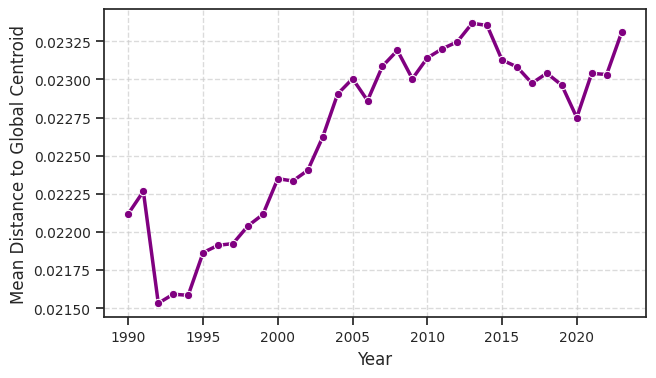

In [41]:
""" Cell 8: Systemic Dispersion & Figure 4 """
metrics = []
for year in sorted(df_ts_clean["year"].unique()):
    df_year = df_ts_clean[df_ts_clean["year"] == year]
    if len(df_year) < 30: # Need critical mass of countries to compute a valid centroid
        continue
        
    # Phase-Space Dispersion (Mean distance to annual centroid)
    centroid = df_year[["Diff1", "Diff2"]].mean().values
    dispersion = np.mean([
        np.linalg.norm(row[["Diff1", "Diff2"]].values - centroid)
        for _, row in df_year.iterrows()
    ])
    
    metrics.append({"Year": year, "Dispersion": dispersion})

df_swarm = pd.DataFrame(metrics)

with plt.rc_context({'text.usetex': False, 'ps.usedistiller': None, 'axes.unicode_minus': False}):
    plt.figure(figsize=(7, 4))
    sns.lineplot(data=df_swarm, x="Year", y="Dispersion", marker='o', color='purple', linewidth=2.5)
    plt.xlabel("Year")
    plt.ylabel("Mean Distance to Global Centroid")
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.savefig("../figures/fig4_global_dispersion.png", dpi=300, bbox_inches='tight')
    plt.savefig("../figures/fig4_global_dispersion.eps", bbox_inches='tight')
    plt.show()